In [ ]:
# with & without libraries

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv
Saving heart.csv to heart.csv
Saving iris.csv to iris.csv


In [ ]:
# iris.csv & diabetes.csv

========== TASK 1: IRIS DATASET ==========
Accuracy Score: 1.0000

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]] 

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



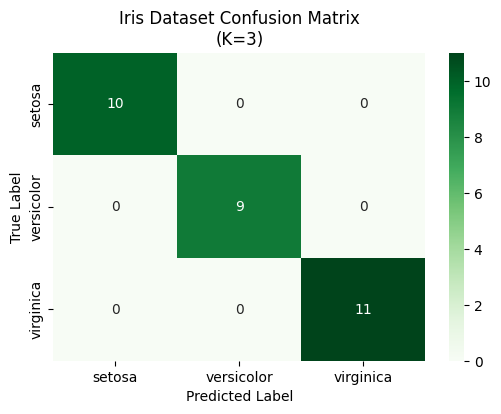



========== TASK 2: DIABETES DATASET ==========
Optimal K value found via Grid Search: 11
Accuracy Score: 0.7078

Confusion Matrix:
 [[78 21]
 [24 31]]


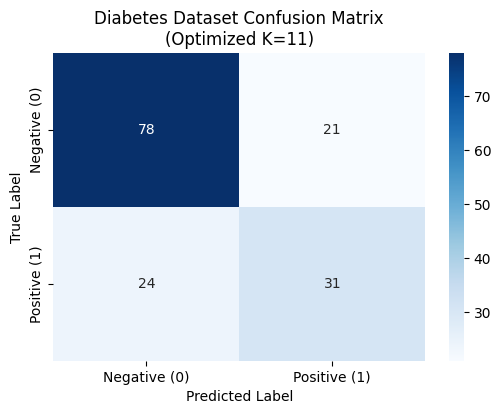

In [ ]:
# using libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def plot_confusion_matrix(cm, classes, title, cmap):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("========== TASK 1: IRIS DATASET ==========")
try:
    iris_df = pd.read_csv("iris.csv")
    X_iris = iris_df.iloc[:, :-1].values
    y_iris = iris_df.iloc[:, -1].values

    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

    knn_iris = KNeighborsClassifier(n_neighbors=3)
    knn_iris.fit(X_train_i, y_train_i)

    y_pred_i = knn_iris.predict(X_test_i)
    acc_iris = accuracy_score(y_test_i, y_pred_i)
    cm_iris = confusion_matrix(y_test_i, y_pred_i)

    print(f"Accuracy Score: {acc_iris:.4f}\n")
    print("Confusion Matrix:\n", cm_iris, "\n")
    print("Classification Report:\n", classification_report(y_test_i, y_pred_i))

    iris_classes = np.unique(y_iris)
    plot_confusion_matrix(cm_iris, iris_classes, 'Iris Dataset Confusion Matrix\n(K=3)', 'Greens')

except FileNotFoundError:
    print("Error: 'iris.csv' not found. Please ensure the file is in the same directory.")

print("\n")



print("========== TASK 2: DIABETES DATASET ==========")
try:
    diabetes_df = pd.read_csv("diabetes.csv")
    X_diab = diabetes_df.iloc[:, :-1].values
    y_diab = diabetes_df.iloc[:, -1].values

    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_d)
    X_test_scaled = scaler.transform(X_test_d)

    param_grid = {'n_neighbors': np.arange(1, 31)}
    knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
    knn_gscv.fit(X_train_scaled, y_train_d)

    best_k = knn_gscv.best_params_['n_neighbors']
    print(f"Optimal K value found via Grid Search: {best_k}")

    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    best_knn.fit(X_train_scaled, y_train_d)

    y_pred_d = best_knn.predict(X_test_scaled)
    acc_diab = accuracy_score(y_test_d, y_pred_d)
    cm_diab = confusion_matrix(y_test_d, y_pred_d)

    print(f"Accuracy Score: {acc_diab:.4f}\n")
    print("Confusion Matrix:\n", cm_diab)

    diab_classes = ['Negative (0)', 'Positive (1)']
    plot_confusion_matrix(cm_diab, diab_classes, f'Diabetes Dataset Confusion Matrix\n(Optimized K={best_k})', 'Blues')

except FileNotFoundError:
    print("Error: 'diabetes.csv' not found. Please ensure it is in the same directory.")

========== TASK 1: IRIS DATASET (FROM SCRATCH) ==========
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:

Class           Precision  Recall     F1-Score  
--------------------------------------------------
setosa          1.00       1.00       1.00      
versicolor      1.00       1.00       1.00      
virginica       1.00       1.00       1.00      



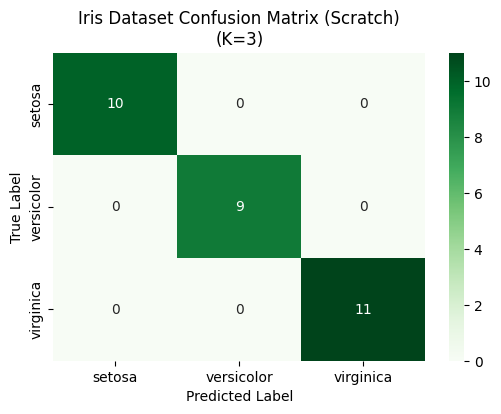



========== TASK 2: DIABETES DATASET (FROM SCRATCH) ==========
Accuracy Score: 0.6928

Confusion Matrix:
[[78 20]
 [27 28]]



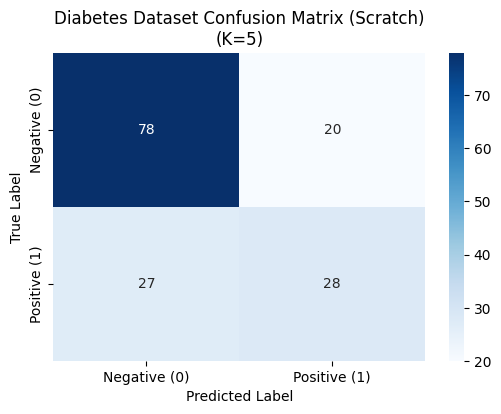

In [ ]:
# without libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


def custom_train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_samples = int(len(X) * test_size)

    test_idx = indices[:test_samples]
    train_idx = indices[test_samples:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def custom_standard_scaler(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)

    X_train_scaled = (X_train - mean) / (std + 1e-8)
    X_test_scaled = (X_test - mean) / (std + 1e-8)
    return X_train_scaled, X_test_scaled

def custom_knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_row in X_test:
        distances = np.sqrt(np.sum((X_train - test_row)**2, axis=1))
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = y_train[k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)[0][0]
        predictions.append(most_common)
    return np.array(predictions)

def custom_confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate((y_true, y_pred)))
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t], class_to_idx[p]] += 1
    return cm, classes

def custom_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def custom_classification_report(y_true, y_pred, classes):
    cm, _ = custom_confusion_matrix(y_true, y_pred)
    report = f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}\n"
    report += "-" * 50 + "\n"

    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        report += f"{str(cls):<15} {precision:<10.2f} {recall:<10.2f} {f1:<10.2f}\n"
    return report

def plot_custom_cm(cm, classes, title, cmap):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


print("========== TASK 1: IRIS DATASET (FROM SCRATCH) ==========")
try:
    iris_df = pd.read_csv("iris.csv")
    X_i = iris_df.iloc[:, :-1].values
    y_i = iris_df.iloc[:, -1].values

    X_train_i, X_test_i, y_train_i, y_test_i = custom_train_test_split(X_i, y_i, test_size=0.2, random_state=42)

    k_iris = 3
    y_pred_i = custom_knn_predict(X_train_i, y_train_i, X_test_i, k_iris)

    cm_i, classes_i = custom_confusion_matrix(y_test_i, y_pred_i)
    print(f"Accuracy Score: {custom_accuracy(y_test_i, y_pred_i):.4f}\n")
    print(f"Confusion Matrix:\n{cm_i}\n")
    print("Classification Report:\n")
    print(custom_classification_report(y_test_i, y_pred_i, classes_i))

    plot_custom_cm(cm_i, classes_i, 'Iris Dataset Confusion Matrix (Scratch)\n(K=3)', 'Greens')

except FileNotFoundError:
    print("Error: 'iris.csv' not found.")

print("\n")

print("========== TASK 2: DIABETES DATASET (FROM SCRATCH) ==========")
try:
    diabetes_df = pd.read_csv("diabetes.csv")
    X_d = diabetes_df.iloc[:, :-1].values
    y_d = diabetes_df.iloc[:, -1].values

    X_train_d, X_test_d, y_train_d, y_test_d = custom_train_test_split(X_d, y_d, test_size=0.2, random_state=42)

    X_train_d_scaled, X_test_d_scaled = custom_standard_scaler(X_train_d, X_test_d)

    k_diab = 5
    y_pred_d = custom_knn_predict(X_train_d_scaled, y_train_d, X_test_d_scaled, k_diab)

    cm_d, classes_d = custom_confusion_matrix(y_test_d, y_pred_d)
    print(f"Accuracy Score: {custom_accuracy(y_test_d, y_pred_d):.4f}\n")
    print(f"Confusion Matrix:\n{cm_d}\n")

    plot_custom_cm(cm_d, ['Negative (0)', 'Positive (1)'], f'Diabetes Dataset Confusion Matrix (Scratch)\n(K={k_diab})', 'Blues')

except FileNotFoundError:
    print("Error: 'diabetes.csv' not found.")

In [ ]:
# heart.csv

--- KNN WITH LIBRARIES ---
Optimal K value: 7 with an accuracy of 0.9180


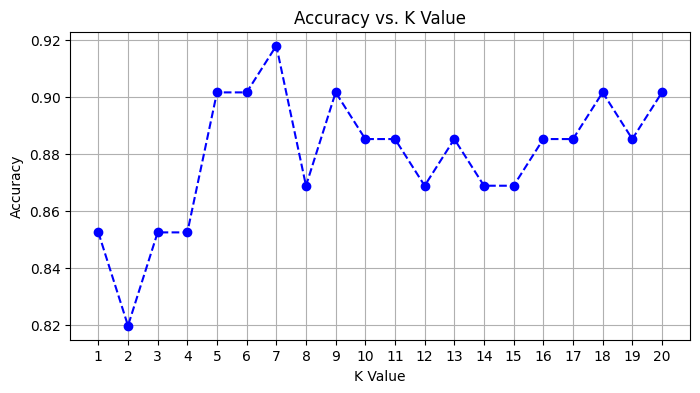

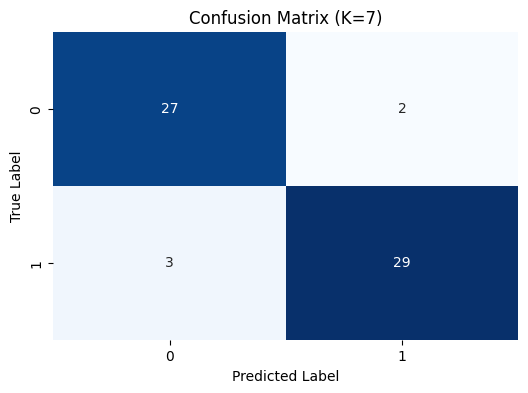

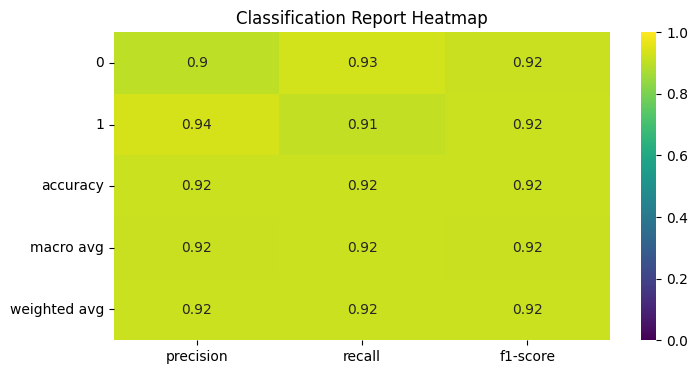

In [ ]:
# with libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("--- KNN WITH LIBRARIES ---")

try:
    df = pd.read_csv('heart.csv')
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    k_values = range(1, 21)
    scores = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)
        scores.append(accuracy_score(y_test, y_pred))

    best_k = k_values[np.argmax(scores)]
    best_score = max(scores)
    print(f"Optimal K value: {best_k} with an accuracy of {best_score:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, scores, marker='o', linestyle='dashed', color='blue')
    plt.title('Accuracy vs. K Value')
    plt.xlabel('K Value')
    plt.ylabel('Accuracy')
    plt.xticks(k_values)
    plt.grid(True)
    plt.show()

    final_knn = KNeighborsClassifier(n_neighbors=best_k)
    final_knn.fit(X_train_scaled, y_train)
    y_pred_final = final_knn.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred_final)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (K={best_k})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    report_dict = classification_report(y_test, y_pred_final, output_dict=True)
    report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

    plt.figure(figsize=(8, 4))
    sns.heatmap(report_df, annot=True, cmap='viridis', vmin=0, vmax=1)
    plt.title('Classification Report Heatmap')
    plt.show()

except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please ensure the file is in the same directory.")

--- KNN FROM SCRATCH ---
Optimal K value: 7 with an accuracy of 0.9167


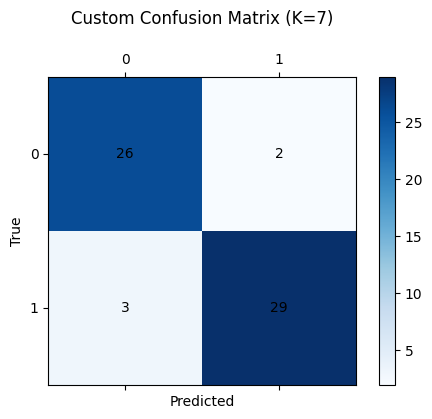

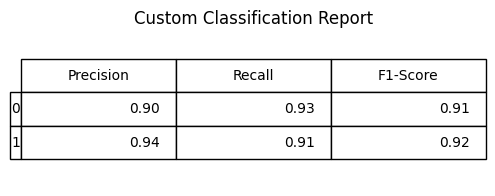

In [ ]:
# without libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("--- KNN FROM SCRATCH ---")

def custom_train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_size = int(len(X) * test_size)
    return X[indices[test_size:]], X[indices[:test_size]], y[indices[test_size:]], y[indices[:test_size]]

def custom_scaler(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    return (X_train - mean) / (std + 1e-8), (X_test - mean) / (std + 1e-8)

def predict_single(x_train, y_train, x_test_row, k):
    distances = np.sqrt(np.sum((x_train - x_test_row)**2, axis=1))
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = y_train[k_indices]
    return Counter(k_nearest_labels).most_common(1)[0][0]

def custom_knn_predict(X_train, y_train, X_test, k):
    return np.array([predict_single(X_train, y_train, row, k) for row in X_test])

def get_confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate((y_true, y_pred)))
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(y_true, y_pred):
        t_idx = np.where(classes == t)[0][0]
        p_idx = np.where(classes == p)[0][0]
        cm[t_idx, p_idx] += 1
    return cm, classes

def get_metrics(cm, classes):
    metrics = {}
    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        metrics[cls] = [precision, recall, f1]
    return metrics

try:
    df = pd.read_csv('heart.csv')
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    X_train, X_test, y_train, y_test = custom_train_test_split(X, y)
    X_train_scaled, X_test_scaled = custom_scaler(X_train, X_test)

    k_values = range(1, 21)
    scores = []

    for k in k_values:
        y_pred = custom_knn_predict(X_train_scaled, y_train, X_test_scaled, k)
        accuracy = np.sum(y_pred == y_test) / len(y_test)
        scores.append(accuracy)

    best_k = k_values[np.argmax(scores)]
    print(f"Optimal K value: {best_k} with an accuracy of {max(scores):.4f}")

    y_pred_final = custom_knn_predict(X_train_scaled, y_train, X_test_scaled, best_k)
    cm, classes = get_confusion_matrix(y_test, y_pred_final)

    fig, ax = plt.subplots(figsize=(6, 4))
    cax = ax.matshow(cm, cmap='Blues')
    plt.title(f'Custom Confusion Matrix (K={best_k})\n')
    fig.colorbar(cax)
    for (i, j), z in np.ndenumerate(cm):
        ax.text(j, i, f'{z}', ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    metrics = get_metrics(cm, classes)
    cell_text = [[f"{v:.2f}" for v in metrics[cls]] for cls in classes]

    fig, ax = plt.subplots(figsize=(6, 2))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=cell_text, rowLabels=classes, colLabels=['Precision', 'Recall', 'F1-Score'], loc='center')
    table.scale(1, 2)
    plt.title('Custom Classification Report')
    plt.show()

except FileNotFoundError:
    print("Error: 'heart.csv' not found.")

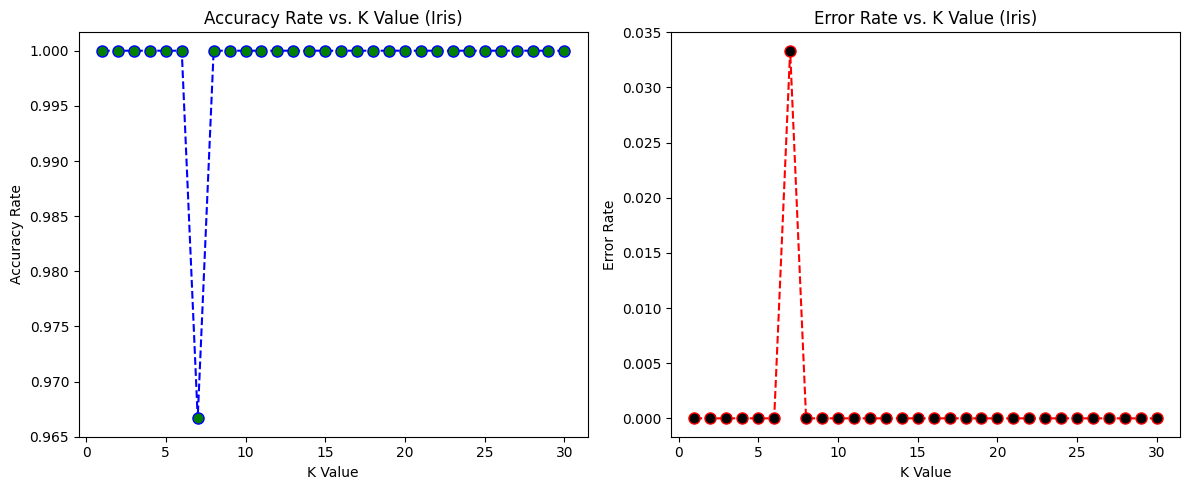

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris_df = pd.read_csv("iris.csv")
X = iris_df.iloc[:, :-1].values
y = iris_df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k_values = range(1, 31)
accuracy_rates = []
error_rates = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy_rates.append(acc)
    error_rates.append(1 - acc)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, accuracy_rates, color='blue', linestyle='dashed', marker='o', markerfacecolor='green', markersize=8)
plt.title('Accuracy Rate vs. K Value (Iris)')
plt.xlabel('K Value')
plt.ylabel('Accuracy Rate')

plt.subplot(1, 2, 2)
plt.plot(k_values, error_rates, color='red', linestyle='dashed', marker='o', markerfacecolor='black', markersize=8)
plt.title('Error Rate vs. K Value (Iris)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

diabetes_df = pd.read_csv("diabetes.csv")
X = diabetes_df.iloc[:, :-1].values
y = diabetes_df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)